## AFRIPRUD STOCK PREDICTION

In [2]:
import pandas as pd

afriprud=pd.read_csv('../stock_data/AFRIPRUD.csv')
afriprud=afriprud.drop(columns=['high_price','low_price'])
afriprud.rename(columns={'trade_date':'date'},inplace=True)
afriprud['date']=pd.to_datetime(afriprud['date'])
afriprud['month']=afriprud['date'].dt.month
afriprud['quarter']=afriprud['date'].dt.quarter
afriprud['year']=afriprud['date'].dt.year

afriprud

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,52070,AFRIPRUD,2017-05-15,2.65,2.65,1306283,2026-04-08T02:52:26.563035+00:00,5,2,2017
1,52162,AFRIPRUD,2017-05-16,2.77,2.77,1970361,2026-04-08T02:52:28.807233+00:00,5,2,2017
2,52254,AFRIPRUD,2017-05-17,2.71,2.71,1383638,2026-04-08T02:52:31.099411+00:00,5,2,2017
3,52346,AFRIPRUD,2017-05-18,2.75,2.75,1194814,2026-04-08T02:52:33.303088+00:00,5,2,2017
4,52438,AFRIPRUD,2017-05-19,2.80,2.80,1704127,2026-04-08T02:52:35.640534+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
2167,298021,AFRIPRUD,2026-07-13,12.70,12.70,1125563,2026-07-13T15:10:02.995074+00:00,7,3,2026
2168,298459,AFRIPRUD,2026-07-14,12.65,12.65,890948,2026-07-14T15:10:03.094441+00:00,7,3,2026
2169,298897,AFRIPRUD,2026-07-15,12.65,12.65,589773,2026-07-15T15:10:03.078609+00:00,7,3,2026
2170,299335,AFRIPRUD,2026-07-16,12.65,12.65,531951,2026-07-16T15:10:03.113936+00:00,7,3,2026


In [4]:
afriprud['close_price'].describe()

count    2172.000000
mean        7.458587
std         5.202005
min         2.650000
25%         4.100000
50%         5.950000
75%         7.500000
max        36.250000
Name: close_price, dtype: float64

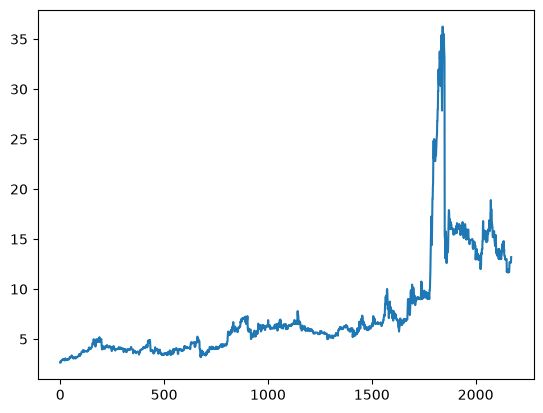

In [5]:
import matplotlib.pyplot as plt

plt.plot(afriprud['close_price'])
plt.show()

In [6]:
afriprud_end_month_df = (
    afriprud
    .sort_values("date")
    .groupby(afriprud["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

afriprud_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,53082,AFRIPRUD,2017-05-31,2.90,2.90,932892,2026-04-08T02:52:57.421655+00:00,5,2,2017
1,54922,AFRIPRUD,2017-06-30,2.90,2.90,1483227,2026-04-08T02:53:53.827964+00:00,6,2,2017
2,56752,AFRIPRUD,2017-07-31,3.20,3.20,5580742,2026-04-08T02:54:52.464984+00:00,7,3,2017
3,58868,AFRIPRUD,2017-08-31,3.12,3.12,707812,2026-04-08T02:55:54.947048+00:00,8,3,2017
4,60524,AFRIPRUD,2017-09-29,3.50,3.50,11550267,2026-04-08T02:56:47.398677+00:00,9,3,2017
...,...,...,...,...,...,...,...,...,...,...
106,35258,AFRIPRUD,2026-03-31,13.60,13.60,1763359,2026-03-31T15:00:02.085058+00:00,3,1,2026
107,281085,AFRIPRUD,2026-04-30,13.05,13.05,6126469,2026-04-30T15:00:02.170664+00:00,4,2,2026
108,284151,AFRIPRUD,2026-05-29,14.00,14.00,1048253,2026-05-29T15:00:02.455558+00:00,5,2,2026
109,294079,AFRIPRUD,2026-06-30,11.65,11.65,1364430,2026-06-30T15:10:03.08168+00:00,6,2,2026


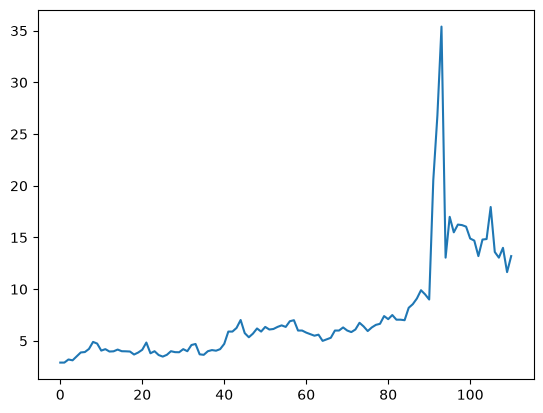

In [7]:
plt.plot(afriprud_end_month_df['close_price'])
plt.show()

In [8]:
afriprud_end_month_df['returns']=afriprud_end_month_df['close_price'].pct_change()*100
afriprud_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,53082,AFRIPRUD,2017-05-31,2.90,2.90,932892,2026-04-08T02:52:57.421655+00:00,5,2,2017,NaN
1,54922,AFRIPRUD,2017-06-30,2.90,2.90,1483227,2026-04-08T02:53:53.827964+00:00,6,2,2017,0.000000
2,56752,AFRIPRUD,2017-07-31,3.20,3.20,5580742,2026-04-08T02:54:52.464984+00:00,7,3,2017,10.344828
3,58868,AFRIPRUD,2017-08-31,3.12,3.12,707812,2026-04-08T02:55:54.947048+00:00,8,3,2017,-2.500000
4,60524,AFRIPRUD,2017-09-29,3.50,3.50,11550267,2026-04-08T02:56:47.398677+00:00,9,3,2017,12.179487
...,...,...,...,...,...,...,...,...,...,...,...
106,35258,AFRIPRUD,2026-03-31,13.60,13.60,1763359,2026-03-31T15:00:02.085058+00:00,3,1,2026,-24.233983
107,281085,AFRIPRUD,2026-04-30,13.05,13.05,6126469,2026-04-30T15:00:02.170664+00:00,4,2,2026,-4.044118
108,284151,AFRIPRUD,2026-05-29,14.00,14.00,1048253,2026-05-29T15:00:02.455558+00:00,5,2,2026,7.279693
109,294079,AFRIPRUD,2026-06-30,11.65,11.65,1364430,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.785714


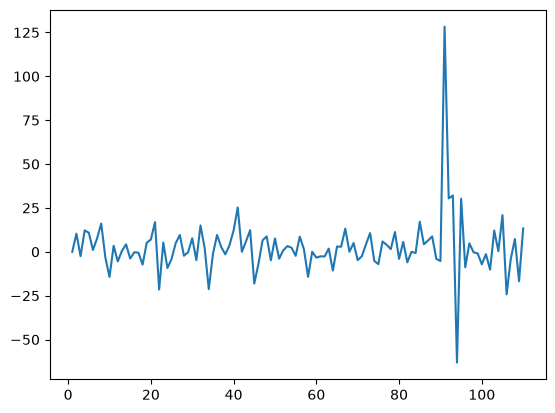

In [9]:
plt.plot(afriprud_end_month_df['returns'])
plt.show()

In [10]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(afriprud_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-7.2281718800507315), np.float64(2.0271697718572033e-10), 2, 107, {'1%': np.float64(-3.492995948509562), '5%': np.float64(-2.888954648057252), '10%': np.float64(-2.58139291903223)}, np.float64(824.517546592769))
stationary


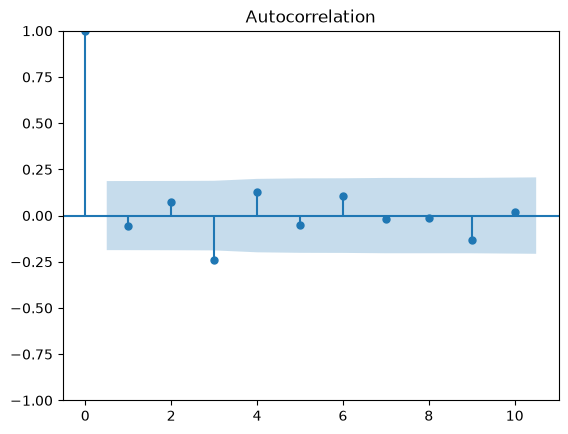

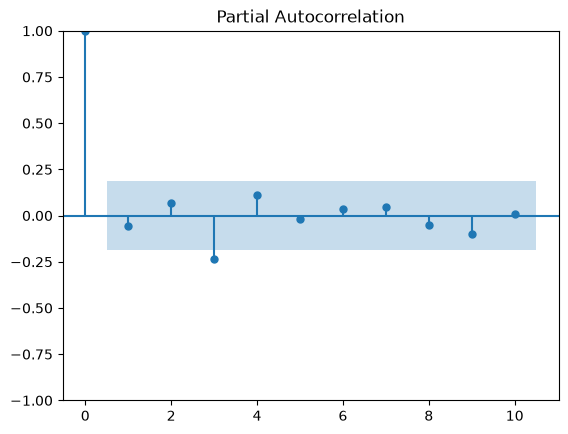

In [11]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(afriprud_end_month_df['returns'].dropna(), lags=10)
plot_pacf(afriprud_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [13]:
train=afriprud_end_month_df['close_price'][:-10]
test=afriprud_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -78.83029341792229]
[0, 0, 0, 0, 0, 1, -11.989093142134465]
[0, 0, 0, 0, 0, 2, -28.994871693289976]
[0, 0, 0, 0, 1, 0, -21.734436954797783]
[0, 0, 0, 0, 1, 1, -64.99045669834067]
[0, 0, 0, 0, 1, 2, -108.23454065214257]
[0, 0, 0, 0, 2, 0, -158.4130650286873]
[0, 0, 0, 0, 2, 1, -217.604492008747]
[0, 0, 0, 0, 2, 2, -241.4514466278033]
[0, 0, 0, 1, 0, 0, -15.263078209671445]
[0, 0, 0, 1, 0, 1, -39.71151793798688]
[0, 0, 0, 1, 0, 2, -34.32522345416549]
[0, 0, 0, 1, 1, 0, -66.20795004392629]
[0, 0, 0, 1, 1, 1, -81.81333173662804]
[0, 0, 0, 1, 1, 2, -72.1651976009984]
[0, 0, 0, 1, 2, 0, -211.9018912060256]
[0, 0, 0, 1, 2, 1, -161.45764022231265]
[0, 0, 0, 1, 2, 2, -208.02763021719403]
[0, 0, 0, 2, 0, 0, -28.67801428082405]
[0, 0, 0, 2, 0, 1, -37.76626894073122]
[0, 0, 0, 2, 0, 2, -49.887440889462944]
[0, 0, 0, 2, 1, 0, -79.73652185462889]
[0, 0, 0, 2, 1, 1, -83.52257832386081]
[0, 0, 0, 2, 1, 2, -87.496486787037]
[0, 0, 0, 2, 2, 0, -216.36557405125947]
[0, 0, 0, 2, 2, 1, -

In [14]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
8,0,0,0,0,2,2,-241.451447
367,1,1,1,1,2,1,-224.252655
26,0,0,0,2,2,2,-221.627141
394,1,1,2,1,2,1,-220.873414
610,2,1,1,1,2,1,-220.035428
...,...,...,...,...,...,...,...
307,1,0,2,1,0,1,0.484359
281,1,0,1,1,0,2,0.518674
290,1,0,1,2,0,2,0.536371
289,1,0,1,2,0,1,0.544829


[1	0	1	1	0	1] is the best score.

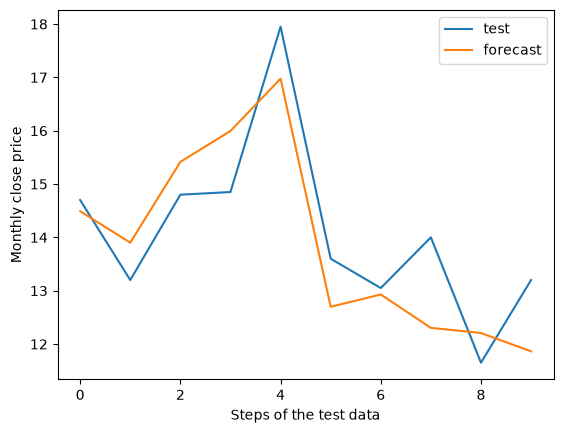

0.6439008159240263
0.9476719591924231


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=afriprud_end_month_df['close_price'][:-10]
y_test=afriprud_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(1,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print(r2_score(y_test, fcst))
print(np.sqrt(mean_squared_error(y_test,fcst)))

In [16]:
afriprud_end_month_df['close_price'].describe()

count    111.000000
mean       7.414505
std        5.109534
min        2.900000
25%        4.085000
50%        5.950000
75%        7.250000
max       35.400000
Name: close_price, dtype: float64

This is a solid performance.